# Week 7 - Quiz

In [1]:
%matplotlib inline
import networkx as nx
import random
from collections import defaultdict
import math
import matplotlib.pyplot as plt
infinity = float('inf')

In [2]:
def visualise(G, directed=False, **kwds):
    if directed:
        G_out = nx.Digraph(**kwds)
    else:
        G_out = nx.Graph(**kwds)
    #dot.attr(rankdir='LR')
    for u in G.keys():
        G_out.add_node(str(u))
        for v in G[u]:
            if directed or u<v:
                G_out.add_edge(str(u), str(v))
    nx.draw_networkx(G_out)

def random_graph(n=12, p=0.3):
    G = defaultdict(list)
    nodes = [chr(ord('A')+i) for i in range(n)]
    for i in range(n):
        src = nodes[i]
        for j in range(i+1, n):
            tgt = nodes[j]
            if random.uniform(0, 1)<p:
                G[src].append(tgt)
                G[tgt].append(src)
    return G

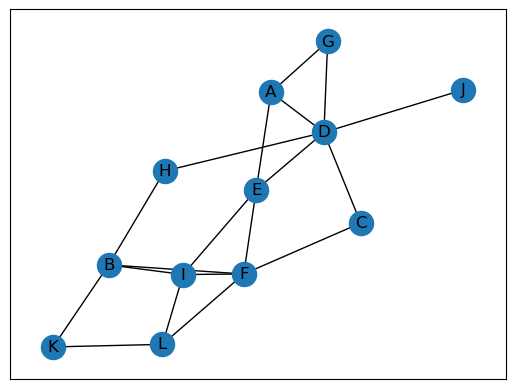

In [3]:
G = random_graph()
visualise(G)

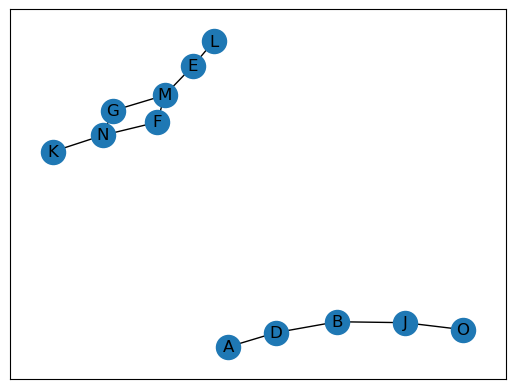

In [4]:
G = random_graph(n=15, p=0.1)
visualise(G)

In [5]:
def dijkstra(G, W, start):
    predecessor = {start: None}   # predecessor subgraph (start has no predecessor)
    q = {start: 0}                # priority queue for next vertices, distance to start is 0
    shortest = {}                 # shortest paths found (none at the start)
    # Repeatedly evaluate this cell until it says Finished!
    while q: # are there any vertices to add?
        # Find the lowest priority (note: this is where the data structure is inefficient!)
        d, vertex = min((d, vertex) for vertex, d in q.items())
        del q[vertex]
        # Add this to the set of vertices we've finished processing
        shortest[vertex] = d
        # Now update the list of candidate vertices by iterating through its neighbours
        for next_vertex in G[vertex]:
            if next_vertex in shortest: # don't add ones we've already finished with
                continue
            c = q.get(next_vertex, infinity) # get the current best found if there is one, or infinity if not
            e = d+W[vertex, next_vertex] # distance to next_vertex if you take this route
            if e<c: # if it's better, replace it in the queue and predecessor subgraph
                q[next_vertex] = e
                predecessor[next_vertex] = vertex
    return shortest, predecessor

0.278: 12-[w=0.167]-18-[w=0.111]-9
50: 0.27778: 50-[w=0.100]-30-[w=0.067]-45-[w=0.111]-9


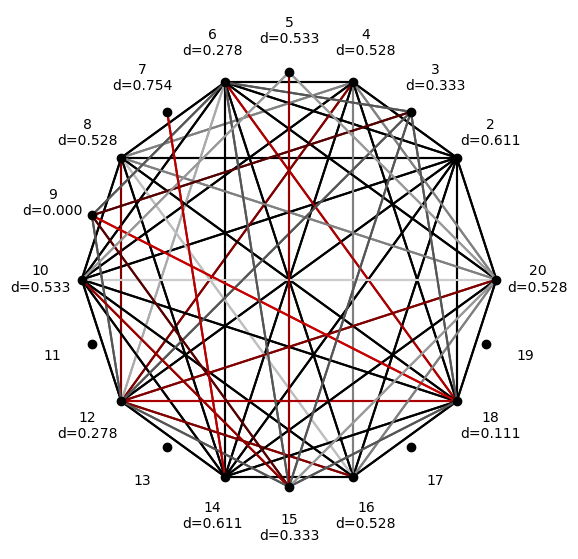

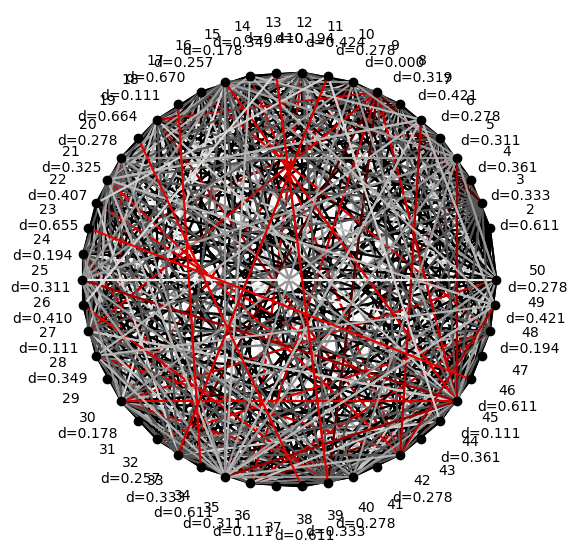

In [6]:
def circle_vis(G, W, shortest, predecessor):
    n = max(G.keys())
    Wmax = max(W.values())
    xy = lambda i, rad=1.0: (rad*math.cos(2*math.pi*i/n), rad*math.sin(2*math.pi*i/n))
    for i, J in G.items():
        for j in J:
            c = [1-W[i, j]/Wmax]*3
            if predecessor.get(i, -1)==j or predecessor.get(j, -1)==i:
                c[1] = c[2] = 0
            plt.plot(*list(zip(*[xy(i), xy(j)])), '-', c=c)
    for i in range(2, n+1):
        plt.plot(*xy(i), 'ok')
        s = str(i)
        if i in shortest:
            s = f'{i}\nd={shortest[i]:.3f}'
        plt.text(*xy(i, rad=1.2), s=s, ha='center', va='center', ma='center')
    plt.xlim(-1.3, 1.3)
    plt.ylim(-1.3, 1.3)
    plt.xticks([])
    plt.yticks([])
    ax = plt.gca()
    ax.set_aspect(1.0)
    ax.set_frame_on(False)
    
def number_graph(n):
    G = defaultdict(list)
    W = {}
    for i in range(1, n+1):
        for j in range(i+1, n+1):
            if math.gcd(i, j)>1:
                G[i].append(j)
                G[j].append(i)
                W[i, j] = W[j, i] = 1/math.gcd(i, j)
    return G, W

def route(G, W, shortest, predecessor, target):
    s = str(target)
    while target in predecessor and predecessor[target] is not None:
        s += f'-[w={W[target, predecessor[target]]:.3f}]-{predecessor[target]}'
        target = predecessor[target]
    return s

plt.figure(figsize=(7,7))

G, W = number_graph(20)
shortest, predecessor = dijkstra(G, W, 9)
circle_vis(G, W, shortest, predecessor)
print(f'{shortest[12]:.3f}:', route(G, W, shortest, predecessor, 12))

plt.figure(figsize=(7,7))

G, W = number_graph(50)
shortest, predecessor = dijkstra(G, W, 9)
circle_vis(G, W, shortest, predecessor)
m = max((len(route(G, W, shortest, predecessor, i)), i) for i in shortest)[1]
print(f'{m}: {shortest[m]:.5f}:', route(G, W, shortest, predecessor, m))
